# GV Exercise – Modular Pipeline Notebook

This notebook demonstrates the exact same data preparation, training, and inference flow as the production code by importing the reusable modules under `src/`.

It intentionally avoids ad-hoc pandas logic so experiments stay aligned with the CLI scripts and MLflow-tracked runs.

In [1]:
%pip install seaborn
%pip install optuna
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Phase 1: Environment Setup

Bootstrap project imports and configuration. This sets up the shared imports, config, and logging so experiments match CLI runs.

In [2]:
import sys
import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import xgboost as xgb

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.common import load_config
from src.common.logging import init_logging
from src.models.io import load_model_bundle
from src.predict.inference import predict_batch
from src.models.training import train_ranker
from src.models.training_pipeline import build_training_dataset
from src.features.pipeline import FeaturePipeline

cfg = load_config()
init_logging(cfg.logging)
cfg


Config(project=ProjectConfig(root=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost')), data=DataConfig(raw_dir=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/data/real'), curated_dir=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/data/training'), training_file=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/data/training/target_variable_training.csv'), schema_version='v1', ranking_files=RankingFiles(founder_experience='founder_experience.csv', education='education.csv', company_info='company_info.csv'), training_files=TrainingFiles(founder_experience='founder_experience_training.csv', education='education_training.csv', company_info='company_info_training.csv')), features=FeatureConfig(registry=PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/data/features'), current_year=2025, selected_columns=['performance', 'education_tier', 'education_level_score', 'founder_has_perf', 'founder_perf_mean', 'founder_perf_max'

## Phase 2: Data Loading & Feature Engineering

Build the training dataset directly from packaged loaders. This pulls packaged training data and cleans it with the same helpers used in production. It also performs manual feature engineering and builds the feature matrix.

### 2.1 Data Loading & Cleaning

Load the raw training data and target labels from the configured data directories.

In [3]:
from src.data.loaders import load_raw, clean, load_targets
raw_training = load_raw(cfg.data, dataset='training')
clean_training = clean(raw_training)
raw_ranking = load_raw(cfg.data, dataset='ranking')
clean_ranking = clean(raw_ranking)
target_df = load_targets(cfg.data)
print('Training:', { 'experience': clean_training.experience.shape, 'education': clean_training.education.shape, 'company_info': clean_training.company_info.shape })
print('Ranking:', { 'experience': clean_ranking.experience.shape, 'education': clean_ranking.education.shape, 'company_info': clean_ranking.company_info.shape })
print('Targets:', target_df.shape, list(target_df.columns))


Training: {'experience': (54616, 12), 'education': (4772, 3), 'company_info': (13898, 3)}
Ranking: {'experience': (1583, 12), 'education': (120, 3), 'company_info': (456, 3)}
Targets: (2000, 4) ['company_id', 'industry', 'company_founded', 'multiple']


### 2.5 Feature Matrix Construction

Build the feature matrix from the clean training data using the initialized pipeline.

In [4]:
training_df = build_training_dataset(clean_training, clean_ranking, target_df, cfg.features)

### 2.7 Manual Feature Engineering

Apply any manual feature engineering steps, such as handling missing values or creating custom flags, and define the final list of feature columns.

In [5]:
# Define feature columns from config
feature_columns = cfg.features.selected_columns

## Phase 3: Data Splitting

Perform per-industry cohort splitting with temporal ordering. We split the data by industry and use temporal ordering (older companies in train, newer in test) to simulate a realistic production scenario.

In [6]:
def temporal_train_val_test_split_by_industry(
    df,
    feature_cols,
    target_col,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
):
    """Per-industry temporal Train/Val/Test split.

    Splits each industry cohort by company_founded into contiguous
    train/validation/test segments and returns frames plus group sizes.
    """

    df = df.copy()
    df = df.dropna(subset=["company_founded"])
    df["industry"] = df["industry"].fillna("Other")

    train_dfs = []
    val_dfs = []
    test_dfs = []
    train_groups = []
    val_groups = []
    test_groups = []
    industry_names = []

    for industry, cohort in df.groupby("industry", sort=False):
        cohort = cohort.sort_values(["company_founded", "company_id", "person_id"])
        n = len(cohort)
        if n < 3:
            train_dfs.append(cohort)
            val_dfs.append(cohort.iloc[0:0])
            test_dfs.append(cohort.iloc[0:0])
            train_groups.append(n)
            val_groups.append(0)
            test_groups.append(0)
            industry_names.append(industry)
            continue

        n_train = max(1, int(n * train_ratio))
        n_val = max(1, int(n * val_ratio))
        if n_train + n_val >= n:
            n_train = max(1, n - 2)
            n_val = 1
        n_test = n - n_train - n_val

        train_cohort = cohort.iloc[:n_train]
        val_cohort = cohort.iloc[n_train:n_train + n_val]
        test_cohort = cohort.iloc[n_train + n_val:]

        train_dfs.append(train_cohort)
        val_dfs.append(val_cohort)
        test_dfs.append(test_cohort)
        industry_names.append(industry)
        train_groups.append(len(train_cohort))
        val_groups.append(len(val_cohort))
        test_groups.append(len(test_cohort))

    train_df = pd.concat(train_dfs, ignore_index=True)
    val_df = pd.concat(val_dfs, ignore_index=True)
    test_df = pd.concat(test_dfs, ignore_index=True)

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_val = val_df[feature_cols]
    y_val = val_df[target_col]
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    return (
        X_train,
        y_train,
        X_val,
        y_val,
        X_test,
        y_test,
        train_df,
        val_df,
        test_df,
        train_groups,
        val_groups,
        test_groups,
        industry_names,
    )

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    train_df,
    val_df,
    test_df,
    train_groups,
    val_groups,
    test_groups,
    industry_names,
) = temporal_train_val_test_split_by_industry(
    df=training_df,
    feature_cols=feature_columns,
    target_col=cfg.features.target_column,
    train_ratio=0.7,
    val_ratio=0.15,
)

print("\n=== Split Summary (Train / Val / Test) ===")
print(f"Total samples: {len(training_df)}")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Number of industry cohorts: {len(industry_names)}")

for idx, industry in enumerate(industry_names):
    train_count = train_groups[idx]
    val_count = val_groups[idx]
    test_count = test_groups[idx]
    total = train_count + val_count + test_count

    train_labels = train_df[train_df["industry"] == industry][cfg.features.target_column]
    val_labels = val_df[val_df["industry"] == industry][cfg.features.target_column]
    test_labels = test_df[test_df["industry"] == industry][cfg.features.target_column]

    print(f"\n{industry}:")
    print(
        f"  Total: {total} | Train: {train_count} ({train_count/total*100:.1f}%)"
        f" | Val: {val_count} ({val_count/total*100:.1f}%)"
        f" | Test: {test_count} ({test_count/total*100:.1f}%)"
    )
    print(f"  Train labels: {dict(sorted(train_labels.value_counts().to_dict().items()))}")
    print(f"  Val labels: {dict(sorted(val_labels.value_counts().to_dict().items()))}")
    print(f"  Test labels: {dict(sorted(test_labels.value_counts().to_dict().items()))}")

print(f"\nTraining rows: {len(training_df)} | Feature columns: {len(feature_columns)}")
train_df.head()


=== Split Summary (Train / Val / Test) ===
Total samples: 4763
Train samples: 3333
Validation samples: 713
Test samples: 717
Number of industry cohorts: 3

Information Technology:
  Total: 2936 | Train: 2055 (70.0%) | Val: 440 (15.0%) | Test: 441 (15.0%)
  Train labels: {0: 1091, 1: 394, 2: 281, 3: 191, 4: 76, 5: 12, 6: 10}
  Val labels: {0: 376, 1: 26, 2: 17, 3: 17, 4: 4}
  Test labels: {0: 426, 1: 7, 2: 5, 5: 3}

Healthcare and Biotech:
  Total: 1018 | Train: 712 (69.9%) | Val: 152 (14.9%) | Test: 154 (15.1%)
  Train labels: {0: 300, 1: 213, 2: 106, 3: 72, 4: 14, 6: 7}
  Val labels: {0: 112, 1: 23, 2: 8, 3: 7, 4: 2}
  Test labels: {0: 135, 1: 15, 2: 4}

Other:
  Total: 809 | Train: 566 (70.0%) | Val: 121 (15.0%) | Test: 122 (15.1%)
  Train labels: {0: 370, 1: 61, 2: 47, 3: 26, 4: 16, 5: 38, 6: 5, 7: 3}
  Val labels: {0: 110, 1: 2, 2: 3, 3: 3, 5: 3}
  Test labels: {0: 122}

Training rows: 4763 | Feature columns: 7


,person_id,company_id,performance,education_tier,education_level_score,founder_has_perf,founder_perf_mean,founder_perf_max,founder_perf_last,industry,is_founder_of_target,company_founded,label
0,SAZwBg4JABobMgcPHywABA==,SBVwFw4GEw0dCgA=,2.804569,5.0,4.0,1,2.804569,2.804569,2.804569,Information Technology,True,1980.0,1
1,SAZwHAAZDDcCCAsIGA==,SBVwFw4GEw0dCgA=,2.804569,2.0,5.0,1,2.140050,2.804569,1.000000,Information Technology,True,1980.0,1
2,SAZwAA4GOgoOHxAEHg==,SBVwGQgIFwcYDBMCKSsRAgMLBwMCAh4pNhoC,9.075158,1.0,2.0,1,9.075158,9.075158,9.075158,Information Technology,True,1982.0,0
3,SAZwAAkECAkcMgcGBCoXCTRVWFo=,SBVwGQgIFwcYDBMCKSsRAgMLBwMCAh4pNhoC,9.075158,3.0,4.0,1,9.075158,9.075158,9.075158,Information Technology,True,1982.0,0
4,SAZwGQAfETcbDBwLGS0rUVpQ,SBVwABQfFhEc,0.780752,3.0,5.0,1,0.780752,0.780752,0.780752,Information Technology,True,1983.0,2


## Phase 4: Data Validation

Quickly verify data integrity by checking for any records with the default '2025' year, which would indicate missing founded dates.

In [7]:
(training_df['company_founded'] == 2025).sum()

np.int64(0)

## Phase 5: Model Training

Train the XGBoost ranker using config-driven hyperparameters. This ensures the training process in the notebook mirrors the production pipeline.

In [8]:
params = cfg.model.hyperparameters.copy()

# Use the validation split as the eval set passed into train_ranker;
# the test split is held out and evaluated separately.
ranker, metrics = train_ranker(
    X_train=X_train,
    y_train=y_train,
    X_test=X_val,
    y_test=y_val,
    train_groups=train_groups,
    test_groups=val_groups,
    industry_names=industry_names,
    params=params,
    tracking_uri=cfg.tracking.uri,
    experiment_name=cfg.tracking.experiment_name,
    run_name=datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
)


/Users/yugu/Desktop/gehirn/gv_case_study/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/11/24 14:47:14 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2025/11/24 14:47:14 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2025/11/24 14:47:14 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: ndcg_at_20
2025/11/24 14:47:14 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have bee


=== Per-Industry NDCG@20 Scores ===
Information Technology:
  Train: 0.4531 | Test: 0.4923
Healthcare and Biotech:
  Train: 0.2237 | Test: 0.3184
Other:
  Train: 0.3839 | Test: 0.8078

=== Mean NDCG@20 ===
Train ndcg@20: 0.3536
Test ndcg@20: 0.5395


In [9]:
from src.models.metrics import calculate_mean_ndcg

test_scores = ranker.predict(X_test)
test_ndcg = calculate_mean_ndcg(
    labels=y_test.tolist(),
    scores=test_scores.tolist(),
    groups=test_groups,
    eval_metric=cfg.model.hyperparameters["eval_metric"],
)
print("Held-out Test ndcg@20:", test_ndcg)


2025/11/24 14:47:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/yugu/Desktop/gehirn/gv_case_study/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Held-out Test ndcg@20: 0.41213157097930214


## Phase 6: Model Persistence

Persist artifacts alongside metadata, identical to the CLI script. This saves the trained model and auxiliary metadata (like feature columns and outcome lookups) to the artifacts directory.

In [10]:
# Persist the trained bundle locally to mirror CLI artifact structure
run_name = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
# Organize notebook runs under timestamped folders for traceability
run_dir = cfg.model.artifact_dir / "notebook_runs" / run_name
run_dir.mkdir(parents=True, exist_ok=True)

model_path = run_dir / "ranker.json"
artifacts_path = run_dir / "artifacts.json"
# Save the booster for reuse in inference cells
ranker.save_model(model_path)

# Bundle auxiliary metadata used during inference
artifacts = {
    "feature_columns": feature_columns,
}
# Persist metadata next to the model bundle
artifacts_path.write_text(json.dumps(artifacts, indent=2))

run_dir


PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/mlruns/models/notebook_runs/20251124T194718Z')

> **Why does `artifacts.json` store company outcomes?**
>
> The mapping is used to label past companies when computing founder experience features (e.g., counting prior 10x exits). Each founder example still receives an individual label during training (`relevance_grade`) and we score founders after training, but we need company-level multiples to quantify their historical track records.

## Phase 7: Inference

Load the freshly written bundle and score current founders. This demonstrates how to reload the saved model and use it to generate predictions for new data.

**Note on SHAP Explanations:**
We enable SHAP value calculation (`shap_top_n=3`) to provide local interpretability for each prediction. The `explanation` column in the output dataframe lists the top 3 features contributing to the score for each founder.

In [11]:
# Reload the saved bundle and score the latest founders
bundle = load_model_bundle(
    registry_cfg=cfg.registry,
    project_root=cfg.project.root,
    model_root=run_dir,
)

# Pull current founders and clean them the same way as training data
raw_ranking = load_raw(cfg.data, dataset="ranking")
clean_ranking = clean(raw_ranking)

# Build the feature matrix for ranking founders using the same feature config
feature_pipeline = FeaturePipeline(cfg.features)
ranking_features = feature_pipeline.build_matrix(clean_ranking)

# Run batch prediction with SHAP explanations enabled (top 3 features)
predictions = predict_batch(bundle, ranking_features, shap_top_n=3)
predictions.head()


,founder_id,industry,score,rank,explanation
0,SAZwFRMGAAYwHgQAHj4ABAcMCQE=,Information Technology,-0.501152,1,"Top factors: performance (-0.64), education_ti..."
1,SAZwAAgMFwkBMgsGDD4GGAoLNx8FOgM=,Information Technology,-0.550775,2,"Top factors: performance (-0.66), education_ti..."
2,SAZwBwQZAg0WMggGBDQbEhIEBg==,Information Technology,-1.067605,3,"Top factors: performance (-0.64), education_ti..."
3,SAZwDgAAOgsAAQA=,Information Technology,-1.101005,4,"Top factors: performance (-0.81), education_ti..."
4,SAZwGAQKDTccBAcCGDoG,Healthcare and Biotech,-1.217574,5,"Top factors: performance (-1.00), education_ti..."


## Phase 8: Ranking Explanation

Visualize the feature importance and impact using SHAP (SHapley Additive exPlanations). This provides a global view of what drives the model's ranking decisions.

SHAP Summary Plot (Global Feature Importance):


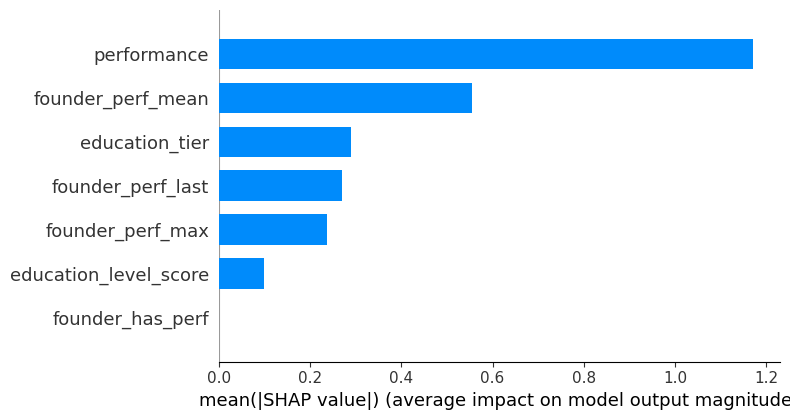

SHAP Beeswarm Plot (Feature Impact Direction):


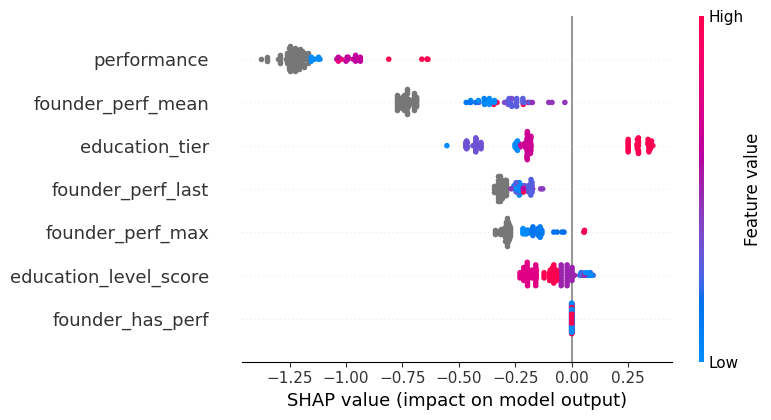


SHAP summary for industry: Healthcare and Biotech (n=13)


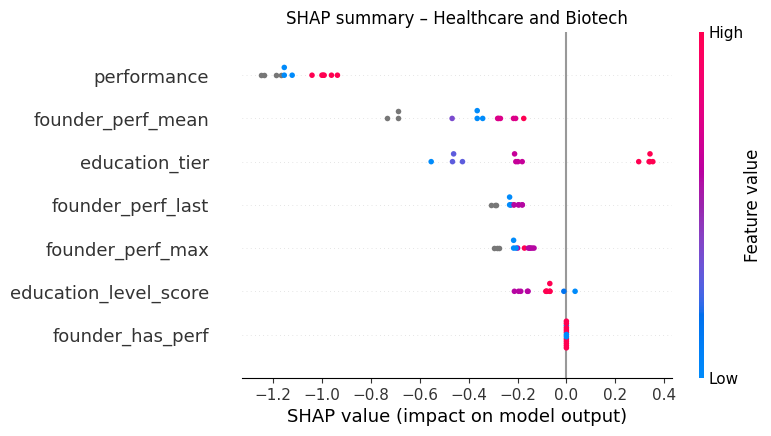


SHAP summary for industry: Information Technology (n=75)


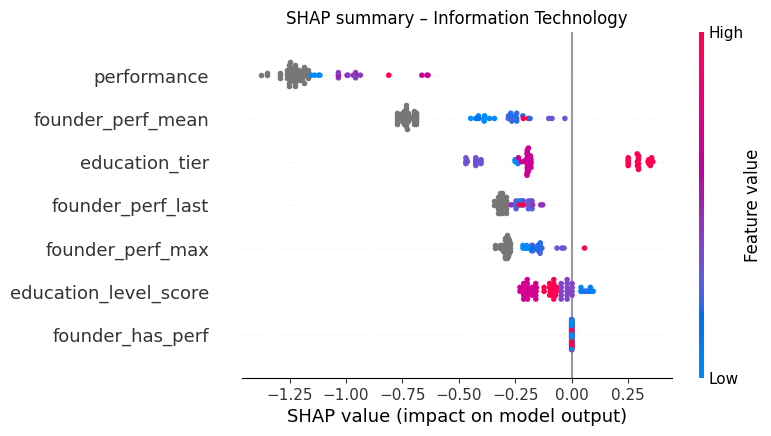


SHAP summary for industry: Other (n=27)


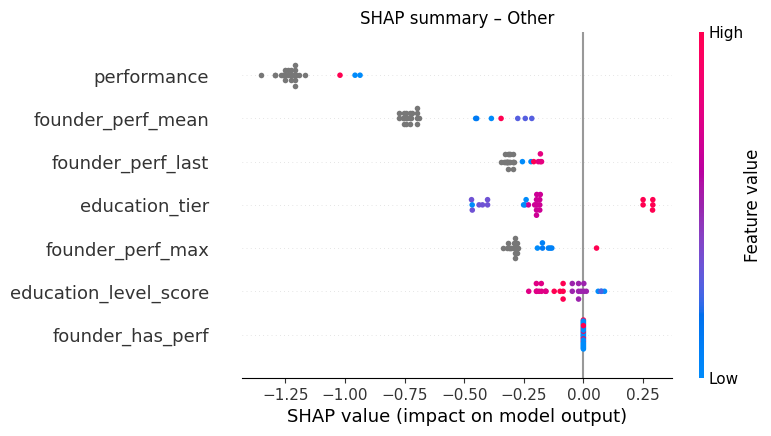

In [12]:
import shap
import matplotlib.pyplot as plt

# Use the estimator from the loaded bundle
model = bundle.estimator

# Select only the feature columns for SHAP calculation
X_ranking = ranking_features.select_columns(bundle.feature_columns)

# Initialize the explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ranking)

# Handle case where shap_values might be a list (for some XGBoost objectives)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

print("SHAP Summary Plot (Global Feature Importance):")
shap.summary_plot(shap_values, X_ranking, plot_type="bar")
plt.show()

print("SHAP Beeswarm Plot (Feature Impact Direction):")
shap.summary_plot(shap_values, X_ranking)
plt.show()

# Per-industry SHAP summary (excluding unknown)
industry_series = ranking_features.frame["industry"]
valid_industries = [
    value
    for value in sorted(industry_series.dropna().unique())
    if isinstance(value, str) and value and value.lower() != "unknown"
]

for industry in valid_industries:
    mask = industry_series == industry
    print(f"\nSHAP summary for industry: {industry} (n={mask.sum()})")
    shap.summary_plot(
        shap_values[mask.values],
        X_ranking[mask.values],
        show=False,
    )
    plt.title(f"SHAP summary – {industry}")
    plt.show()
